<a href="https://colab.research.google.com/github/elzbietapiechota/Clustering/blob/main/Clustering_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [89]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from matplotlib.colors import LogNorm
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [90]:
def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=3, linewidths=8,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(klasyfikator, X):
    # wyznaczanie granic decyzyjnych, podobnie jak w poprzednich notatnikach
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 100),
                         np.linspace(mins[1], maxs[1], 100))
    Z = klasyfikator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # rysowanie konturów granic
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")

    # rysowanie danych
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    # centra klastrów można wyciągnąc za pomocą zmiennej cluster_centers_
    plot_centroids(klasyfikator.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [91]:
def plot_dbscan(dbscan, X, size):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

In [92]:
def plot_gaussian_mixture(clf, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clf.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, linewidths=3, colors='b')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

    plt.xlabel("$x_1$", fontsize=14)
    plt.tick_params(labelleft=False)

# Klasteryzacja

Wczytanie zbioru danych

In [93]:
# Pobieranie paczki ZIP z Dysku Google
FILE_ID = "1jFsA0qoMweFOgn0U4wPYUIWpDzu9ahVO"
URL = f"https://://google.com?export=download&id={FILE_ID}&confirm=t"

os.system(f'wget --no-check-certificate "{URL}" -O samsung_data.zip')
os.system("unzip -o samsung_data.zip")

2304

In [94]:
X_train_raw = pd.read_csv('samsung_train.txt', sep=r'\s+', header=None)
X_test_raw = pd.read_csv('samsung_test.txt', sep=r'\s+', header=None)
X_all = np.r_[X_train_raw, X_test_raw]
print(f"Liczba cech: {X_all.shape[1]}")

Liczba cech: 561


Zmniejszenie liczby cech

In [95]:
X_all_df = pd.DataFrame(X_all)

# Filtr wariancji
X_filtered = X_all_df.loc[:, X_all_df.var() >= 0.05]

# Filtr korelacji
upper_tri = X_filtered.corr().abs().unstack().drop_duplicates()
to_drop = [pair[1] for pair in upper_tri[(upper_tri > 0.50) & (upper_tri < 1.0)].index]
X_final_features = X_filtered.drop(columns=set(to_drop))
X_final_features.columns = range(X_final_features.shape[1])

print(f"Liczba cech: {X_final_features.shape[1]}")

Liczba cech: 44


Skalowanie danych i przygotowanie dwóch cech do wizualizacji

In [96]:
# Skalowanie danych
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_final_features)

# Dane 2d do wizualizacji
X_for_plot = X_scaled[:, [0, 1]]

Klastering - KMeans

In [97]:
model_kmeans = KMeans(n_clusters=6, random_state=42)
y_kmeans = model_kmeans.fit_predict(X_scaled)

Wizualizacja KMeans

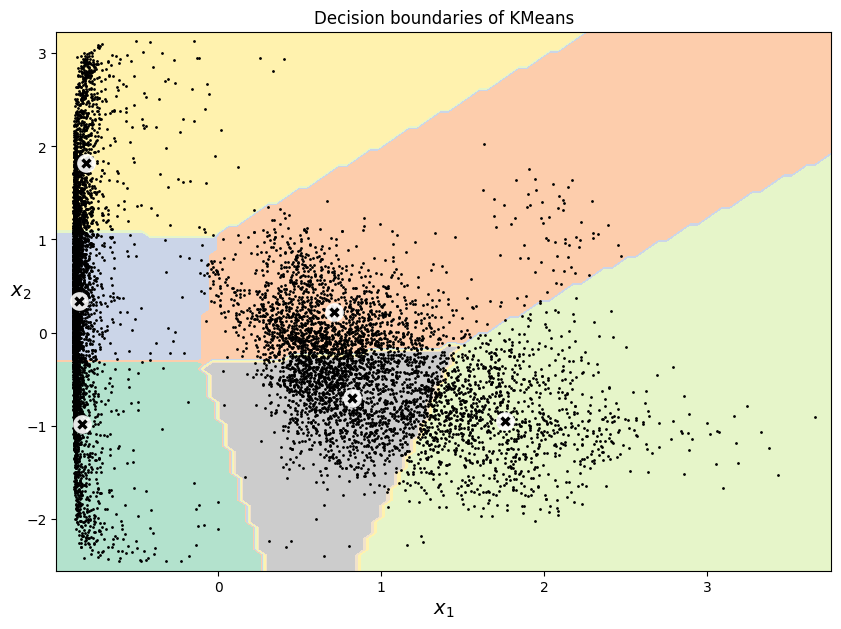

In [98]:
# Trenowanie modelu na dwóch cechach
model_kmeans_2d = KMeans(n_clusters=6, random_state=42)
model_kmeans_2d.fit(X_for_plot)

plt.figure(figsize=(10, 7))
plot_decision_boundaries(model_kmeans_2d, X_for_plot)
plt.title("Decision boundaries of KMeans")
plt.show()

Klastering - MiniBatchKMeans

In [99]:
model_mbkmeans = MiniBatchKMeans(n_clusters=6, max_iter=100, random_state=42)
y_mbkmeans = model_mbkmeans.fit_predict(X_scaled)

Wizualizacja MiniBatchKmeans

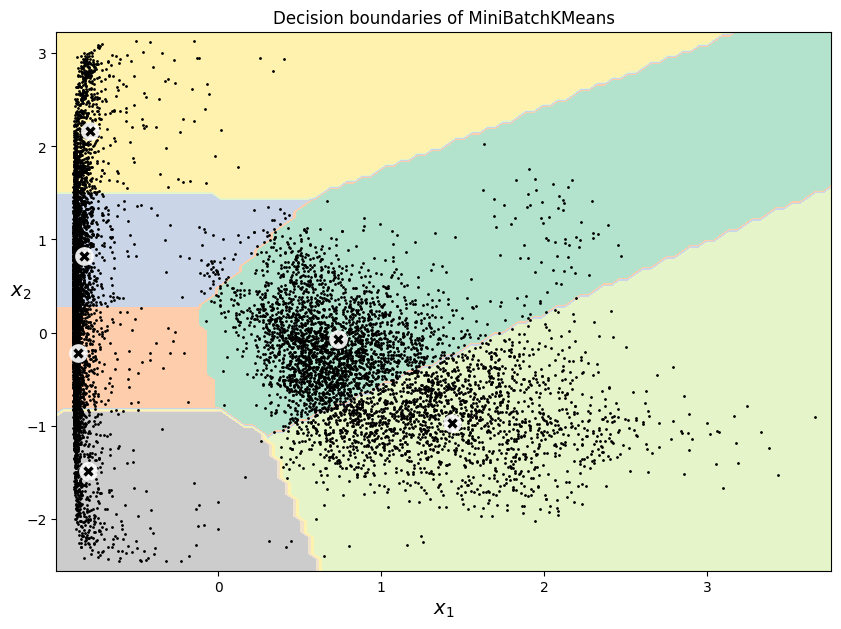

In [100]:
# Trenowanie modelu na dwóch cechach
model_mbkmeans_2d = MiniBatchKMeans(n_clusters=6, max_iter=100, random_state=42)
model_mbkmeans_2d.fit(X_for_plot)

plt.figure(figsize=(10, 7))
plot_decision_boundaries(model_mbkmeans_2d, X_for_plot)
plt.title("Decision boundaries of MiniBatchKMeans")
plt.show()

Klastering - DBSCAN

In [101]:
model_dbscan = DBSCAN(eps=0.05, min_samples=5)
y_dbscan = model_dbscan.fit_predict(X_scaled)

model_dbscan_2 = DBSCAN(eps=0.2, min_samples=5)
y_dbscan_2 = model_dbscan_2.fit_predict(X_scaled)

Wizualizacja - DBSCAN

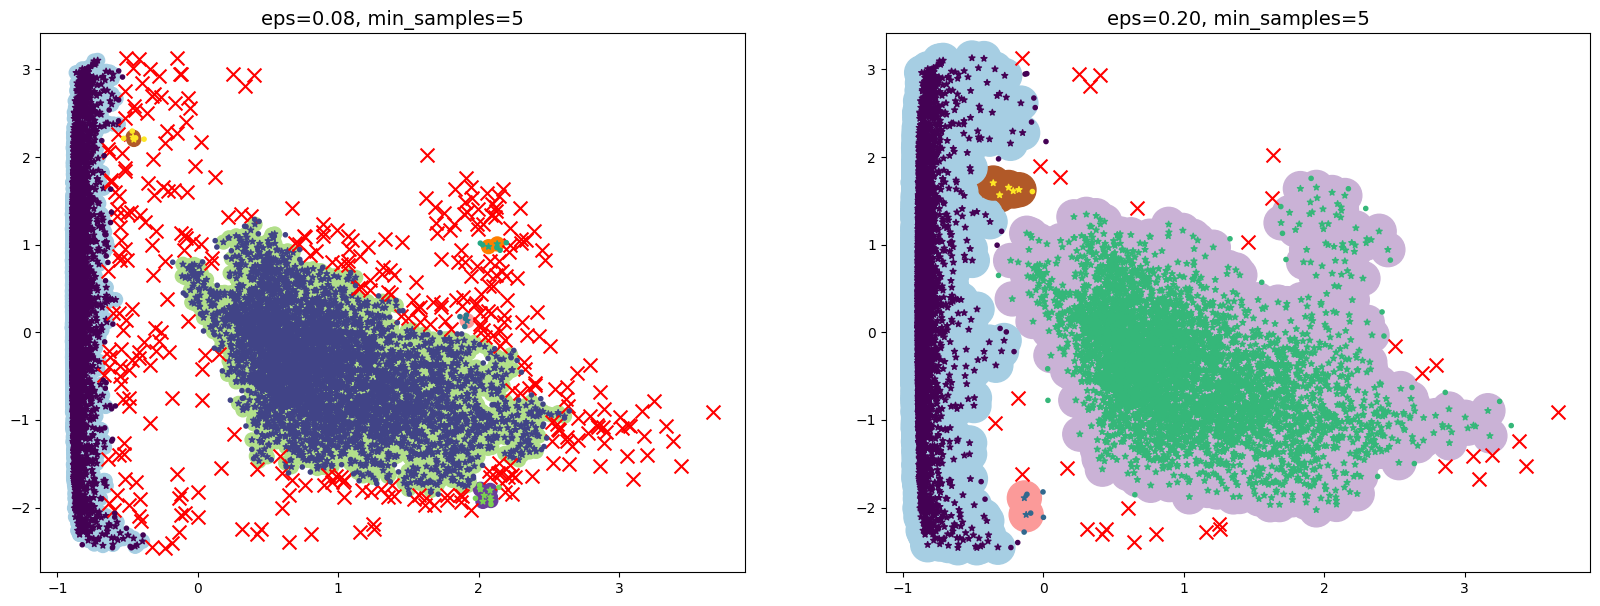

In [102]:
# Trenowanie modelu na dwóch cechach
model_dbscan_2d = DBSCAN(eps=0.08, min_samples=5)
y_dbscan = model_dbscan_2d.fit_predict(X_for_plot)

model_dbscan_2_2d = DBSCAN(eps=0.2, min_samples=5)
y_dbscan_2 = model_dbscan_2_2d.fit_predict(X_for_plot)

plt.figure(figsize=(20, 7))

plt.subplot(121)
plot_dbscan(model_dbscan_2d, X_for_plot, size=100)

plt.subplot(122)
plot_dbscan(model_dbscan_2_2d, X_for_plot, size=600)

plt.show()

Klasteryzacja - GMM

In [103]:
model_gmm = GaussianMixture(n_components=6, n_init=5, random_state=42)
y_gmm = model_gmm.fit_predict(X_scaled)

Wizualizacja GMM

/tmp/ipykernel_11340/1685126341.py:9: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contourf(xx, yy, Z,
/tmp/ipykernel_11340/1685126341.py:12: UserWarning: Log scale: values of z <= 0 have been masked
  plt.contour(xx, yy, Z,


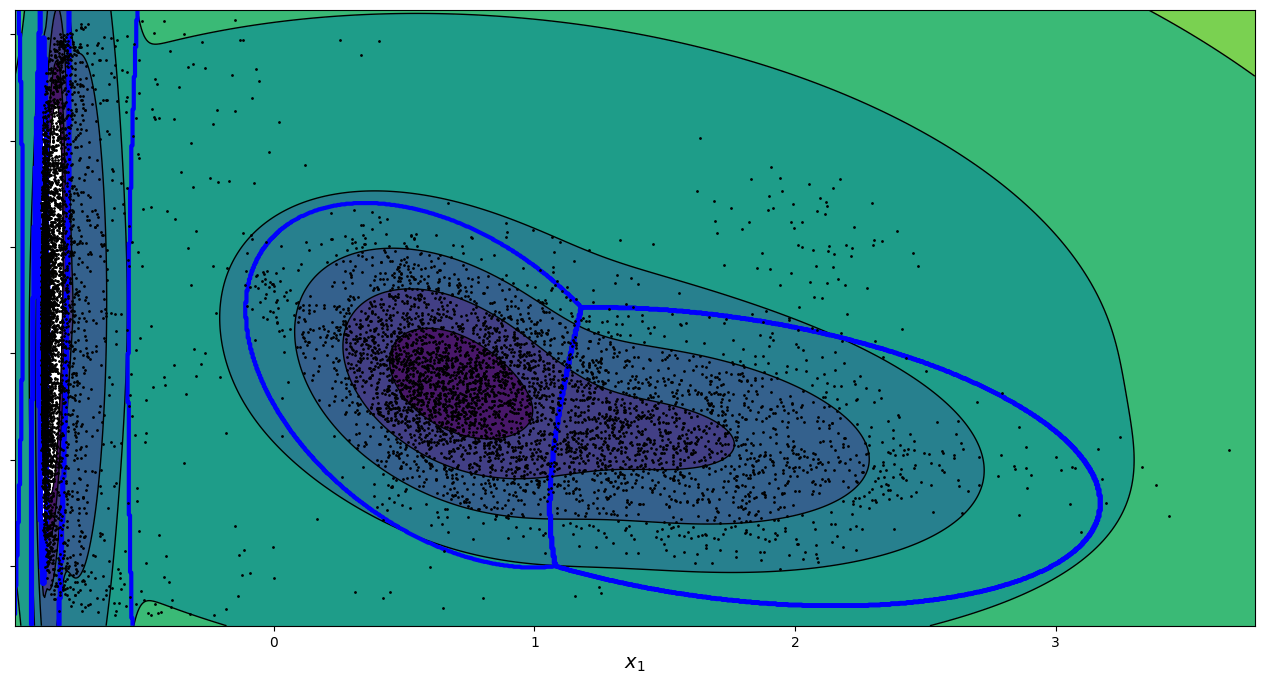

In [104]:
model_gmm_2d = GaussianMixture(n_components=6, n_init=5, random_state=42)
model_gmm_2d.fit(X_for_plot)

plt.figure(figsize=(16, 8))

plot_gaussian_mixture(model_gmm_2d, X_for_plot)
plt.show()

Ocena modeli

In [105]:
# Wczytanie prawdziwych etykiet
y_train_raw = pd.read_csv('samsung_train_labels.txt', header=None)
y_test_raw = pd.read_csv('samsung_test_labels.txt', header=None)
y_all = np.r_[y_train_raw, y_test_raw].flatten()

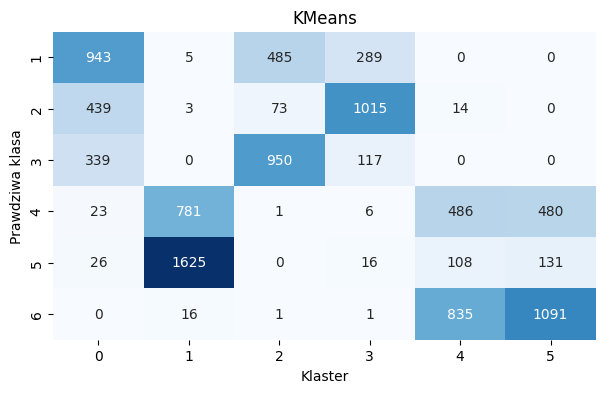

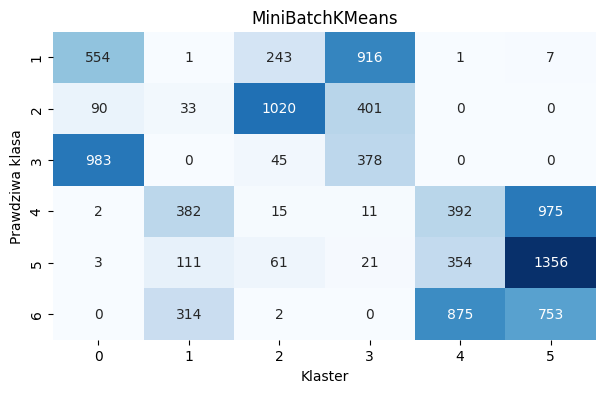

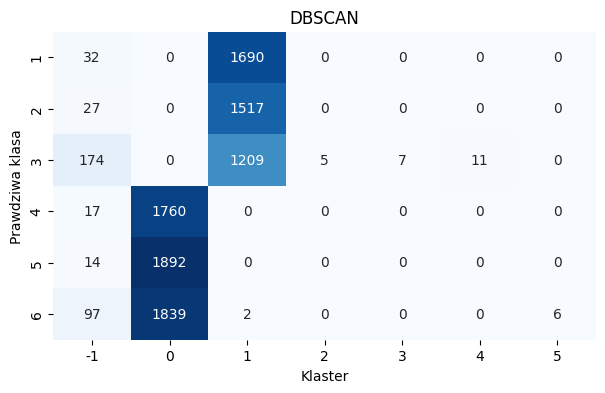

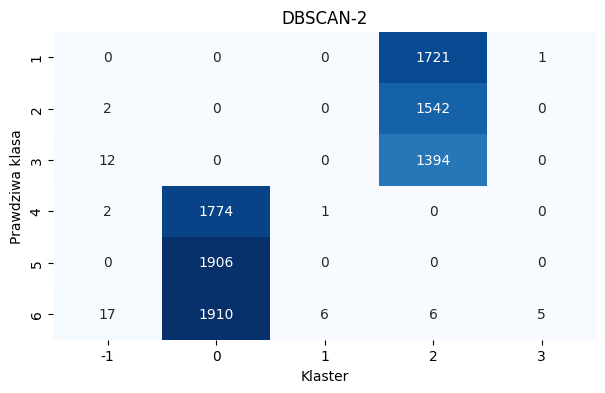

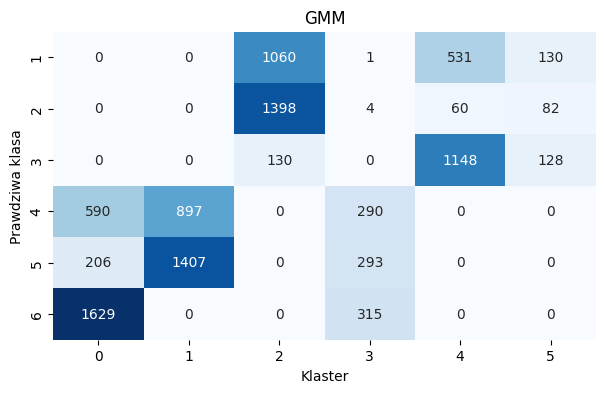

In [106]:
# Porównanie prawdziwych etykiet i klastrów modeli
models = [
    ("KMeans", y_kmeans),
    ("MiniBatchKMeans", y_mbkmeans),
    ("DBSCAN", y_dbscan),
    ("DBSCAN-2", y_dbscan_2),
    ("GMM", y_gmm)]

for name, predictions in models:
    ct = pd.crosstab(y_all, predictions, rownames=["Prawdziwa klasa"], colnames=["Klaster"])

    plt.figure(figsize=(7, 4))
    sns.heatmap(ct, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"{name}")
    plt.show()

KMeans i MiniBatchKMenas poradziły sobie najlepiej ze staniem (5), natomiast najgorzej z leżeniem (6). DBSCAN wykrył 6 klastrów, jednakże i tak większość czynności zaklasyfikował do dwóch klastrów. Podobnie DBSCAN-2, który wykrył 4 klastry. GMM najlepiej poradził sobie z leżeniem (6), a najgorzej z siedzeniem (4).

Wybór ilości klastrów dla KMeans

In [107]:
kmeans_per_k = [
    KMeans(n_clusters=k, random_state=2).fit(X_scaled)
    for k in range(2, 20)
]

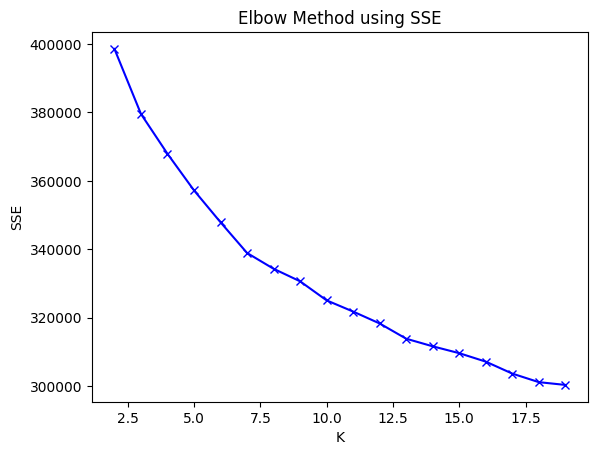

In [108]:
inertias = [model.inertia_ for model in kmeans_per_k]
plt.plot(range(2, 20), inertias, 'bx-')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('Elbow Method using SSE')
plt.show()

In [109]:
silhouette_scores = [
    silhouette_score(X_scaled, model.labels_, sample_size=2000, random_state=42)
    for model in kmeans_per_k
]

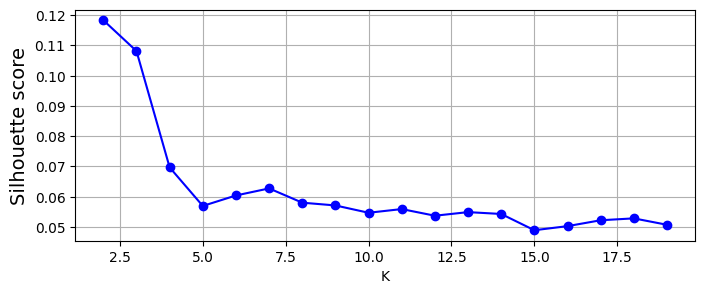

In [110]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 20), silhouette_scores, "bo-")
plt.xlabel('K')
plt.ylabel("Silhouette score", fontsize=14)
plt.grid()
plt.show()

# Preprocessing - klastering na potrzeby klasyfikacji

In [111]:
# Wczytanie surowych danych
X_train_raw = pd.read_csv("samsung_train.txt", sep=r"\s+", header=None)
X_test_raw = pd.read_csv("samsung_test.txt", sep=r"\s+", header=None)

y_train = pd.read_csv("samsung_train_labels.txt", header=None).values.flatten()
y_test = pd.read_csv("samsung_test_labels.txt", header=None).values.flatten()

In [112]:
# Filtr wariancji
train_vars = X_train_raw.var()
selected_variance_cols = train_vars[train_vars >= 0.05].index

X_train_filtered = X_train_raw[selected_variance_cols]
X_test_filtered = X_test_raw[selected_variance_cols]

# Filtr korelacji
upper_tri = X_train_filtered.corr().abs().unstack().drop_duplicates()
to_drop = [
    pair[1]
    for pair in upper_tri[(upper_tri > 0.50) & (upper_tri < 1.0)].index]

# Dane po filtracji
X_train_final = X_train_filtered.drop(columns=set(to_drop))
X_test_final = X_test_filtered.drop(columns=set(to_drop))

print(f"Liczba cech po filtracji: {X_train_final.shape[1]}")

Liczba cech po filtracji: 45


In [113]:
# Skalowanie danych
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

In [114]:
# KMeans i LogisticRegression z GridSearchCV
base_pipeline_lr = Pipeline([
    ("kmeans", KMeans(
        random_state=42,
        n_init=5)),
    ("log_reg", LogisticRegression(
        max_iter=5000,
        random_state=42))])

param_lr = {
    "kmeans__n_clusters": [10, 20, 40],
    "log_reg__C": [0.1, 1.0, 10.0]}

final_lr = GridSearchCV(base_pipeline_lr, param_lr, cv=5, scoring="accuracy", n_jobs=-1)

final_lr.fit(X_train_scaled, y_train)

print(f"\n[Regresja Logistyczna - Najlepsze wyniki]")
print(f"Wybrane parametry: {final_lr.best_params_}")
print(f"Wynik CV (Train):  {final_lr.best_score_:.4f}")
print(f"Wynik na TEST:     {final_lr.score(X_test_scaled, y_test):.4f}")

# KMeans i DecisionTree z GridSearchCV
base_pipeline_dt = Pipeline([
    ("kmeans", KMeans(
        random_state=42,
        n_init=5)),
    ("dec_tree", DecisionTreeClassifier(
        max_depth=10,
        random_state=42))])

param_dt = {
    "kmeans__n_clusters": [10, 20, 40],
    "dec_tree__max_depth": [5, 10, 15]}

final_dt = GridSearchCV(base_pipeline_dt, param_dt, cv=5, scoring="accuracy", n_jobs=-1)

final_dt.fit(X_train_scaled, y_train)

print(f"\n[Drzewo Decyzyjne - Najlepsze wyniki]")
print(f"Wybrane parametry: {final_dt.best_params_}")
print(f"Wynik CV (Train):  {final_dt.best_score_:.4f}")
print(f"Wynik na TEST:     {final_dt.score(X_test_scaled, y_test):.4f}")


[Regresja Logistyczna - Najlepsze wyniki]
Wybrane parametry: {'kmeans__n_clusters': 40, 'log_reg__C': 1.0}
Wynik CV (Train):  0.8643
Wynik na TEST:     0.8466

[Drzewo Decyzyjne - Najlepsze wyniki]
Wybrane parametry: {'dec_tree__max_depth': 10, 'kmeans__n_clusters': 20}
Wynik CV (Train):  0.7338
Wynik na TEST:     0.6719


Wizualizacja oceny modelu

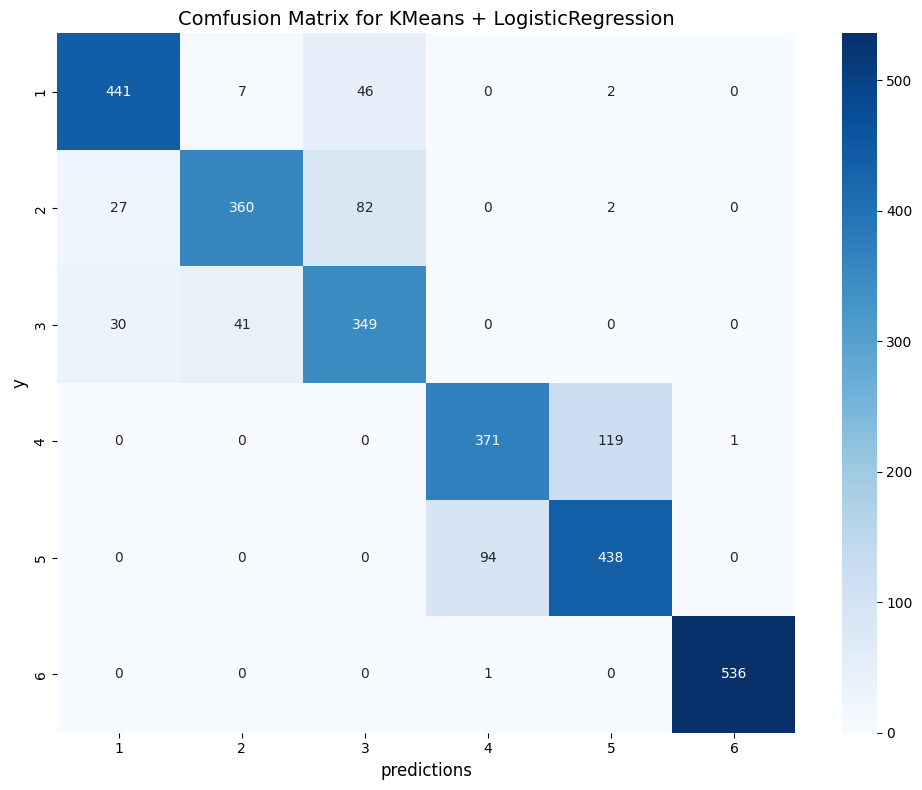

In [115]:
# Macierz pomyłek
y_pred = final_lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)
class_numbers = np.unique(y_test)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_numbers,
    yticklabels=class_numbers)

plt.title("Comfusion Matrix for KMeans + LogisticRegression", fontsize=14)
plt.ylabel("y", fontsize=12)
plt.xlabel("predictions", fontsize=12)
plt.tight_layout()
plt.show()

# Czym różni się KMeans, K-fold i K Nearest Neighbors?



*   **KMeans** - jest algorytmem uczenia nienadzorowanego, który samoczynnie wykonuje klasteryzację (podział zbioru danych na grupy), gdzie "K" oznacza liczbę klastrów, wyselekcjonowanych według wspólnych cech danych. KMeans otrzymuje wyłącznie cechy (X) do nauki, a jego nauka polega na szukaniu naturalnych skupisk i wzorców geometrycznych w danych.

*   **K-Fold** - jest metodą występującą w kroswalidacji, polegającą na wielokrotnym podzieleniu danych treningowych na części, nauczeniu i przetestowaniu modelu na każdej z nich, gdzie "K" oznacza liczbę foldów (części). Użycie KFold pozwala uzyskać niezależną ocenę modelu dla każdego z foldów, dzięki czemu otrzymuje się rzetelną informację o dokładności modelu i o jego stabilności.

*   **K Nearest Neighbors** - jest algorytmem uczenia nadzorowanego, który wykonuje klasyfikację danych przewidując ich etykiety (klasy), poprzez sprawdzenie etykiet "K" najbliższych sąsiadów punktu na wykresie i wybierając większość. KNN otrzymuje do anuki zarówno cechy (X), jak i wyniki (y), a jego nauka polega na zapisaniu w pamięci współrzędnych punktów oraz informacji, do jakiej klasy każdy z tych punktów należy, aby potem móc porównać do nich nowe próbki (szukać sąsiadów).